In [2]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(ComplexHeatmap)
library(harmony)
library(ggsci)
library(ComplexHeatmap)
library(grid)
library(circlize)
library(scatterpie)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: Rcpp

circlize version 0.4.16
CRAN page: https://cran.r-project.or

In [105]:
#umap <- reticulate::import("umap")

In [3]:
multi_colpalettes<-unique(c(pal_igv("default")(51),pal_npg("nrc")(10),pal_aaas("default")(10),pal_nejm("default")(8),pal_lancet("lanonc")(9),
                      pal_jama("default")(7),pal_jco("default")(10),pal_ucscgb("default")(26),pal_d3("category10")(10),
                      pal_locuszoom("default")(7),
                      pal_uchicago("default")(9),pal_startrek("uniform")(7),
                      pal_tron("legacy")(7),pal_futurama("planetexpress")(12),pal_rickandmorty("schwifty")(12),
                      pal_simpsons("springfield")(16),pal_gsea("default")(12)))
Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')

In [4]:
OG_gene <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups.tsv',sep='\t',row.names = 1)
OG_gene2 <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups_UnassignedGenes.tsv',sep='\t',row.names = 1)
OG_gene <- rbind(OG_gene,OG_gene2)

readRDS_process <- function(path){
    obj <- readRDS(path)
    obj@assays$RNA@meta.features <- OG_gene[rownames(obj),]
    return(obj)
}

In [4]:
obj_IN <- readRDS('obj_GABA.rds')

In [ ]:
#strategy 1: Use marker to integrated
obj <- obj_IN
feature_num <- 1500
obj@active.assay <- 'RNA'

#Use the conserved orthgroup matrix
intersection_OG <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_intersection_1028.csv',row.names = 1)
use_orthgroup <- intersection_OG[intersection_OG$Number>=5,'V1']
use_orthgroup <- unique(c(use_orthgroup,marker_features))
raw_assays <- obj[['RNA']]@counts
obj <- CreateSeuratObject(obj@assays$RNA@counts[rownames(obj)%in%use_orthgroup,],meta.data=obj@meta.data)

#Integrated batch
obj@meta.data$integrated_batch <- obj@meta.data$batch
obj.list <- lapply(unique(obj$integrated_batch),function(x){return(obj[,obj$integrated_batch==x])})
obj.list <- lapply(X = obj.list, FUN = SCTransform)
SCT_marker_features <- unlist(lapply(X = obj.list, function(obj_tmp){
    return(intersect(rownames(obj_tmp@assays$SCT),marker_features))
}))
SCT_marker_features <- names(table(SCT_marker_features))[table(SCT_marker_features)==length(obj.list)]
obj.list <- lapply(X = obj.list, function(obj_tmp){
    obj_tmp@active.assay <- 'SCT'
    obj_tmp@assays$SCT@var.features <- unique(c(obj_tmp@assays$SCT@var.features,SCT_marker_features))
    obj_tmp <- ScaleData(obj_tmp,verbose = F)
    return(obj_tmp)
})
#features <- SelectIntegrationFeatures(object.list = obj.list,nfeatures = feature_num)
#features <- unique(c(features,SCT_marker_features))
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = SCT_marker_features)
obj.anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT", k.anchor = 20,
                                              reference = grep(FALSE,duplicated(gsub('_.*','',unique(obj$integrated_batch)))),anchor.features = SCT_marker_features)
obj <- IntegrateData(anchorset = obj.anchors, normalization.method = "SCT",k.weight = 100)


obj[['RNA']] <- CreateAssayObject(raw_assays[,colnames(obj)])
#Run seurat pipline
DefaultAssay(obj) <- "integrated"
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)


saveRDS(obj,'obj_GABA_integrated_20251114.rds')

In [31]:
#strategy 2: Normal integrated
obj <- obj_IN
feature_num <- 2500
obj@active.assay <- 'RNA'

#Use the conserved orthgroup matrix
intersection_OG <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_intersection_1028.csv',row.names = 1)
use_orthgroup <- intersection_OG[intersection_OG$Number>=5,'V1']
raw_assays <- obj[['RNA']]@counts
obj <- CreateSeuratObject(obj@assays$RNA@counts[rownames(obj)%in%use_orthgroup,],meta.data=obj@meta.data)

#Integrated batch
obj@meta.data$integrated_batch <- obj@meta.data$species

obj.list <- lapply(unique(obj$integrated_batch),function(x){return(obj[,obj$integrated_batch==x])})
obj.list <- lapply(X = obj.list, FUN = SCTransform)
features <- SelectIntegrationFeatures(object.list = obj.list,nfeatures = feature_num)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)
obj.anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT", k.anchor = 20,
                                              reference = grep(FALSE,duplicated(gsub('_.*','',unique(obj$integrated_batch)))),anchor.features = features)
obj <- IntegrateData(anchorset = obj.anchors, normalization.method = "SCT",k.weight = 100)

obj[['RNA']] <- CreateAssayObject(raw_assays[,colnames(obj)])

#Run seurat pipline
DefaultAssay(obj) <- "integrated"
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)

saveRDS(obj,'obj_GABA_integrated.rds')

#Delete the cluster is MIX GLU neuron
DefaultAssay(obj) <- "integrated"
obj <- obj[,obj$integrated_snn_res.0.5!=5]
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)

#Annotation
obj$Subclass <- 'None'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(0),]$Subclass <- 'MGE.PVALB'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(9),]$Subclass <- 'MGE.PVALB-POSTN'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(2,5),]$Subclass <- 'MGE.SST'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(3),]$Subclass <- 'CGE.VIP'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(6),]$Subclass <- 'CGE.RELN'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(8),]$Subclass <- 'CGE.LAMP5-RELN'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(4),]$Subclass <- 'CGE.LAMP5'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(10),]$Subclass <- 'CGE.LAMP5-PRKG1'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(7),]$Subclass <- 'LGE.TSHZ1'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(1),]$Subclass <- 'LGE.FOXP1'
saveRDS(obj,'obj_GABA_integrated_20251114.rds')

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 11623 by 7552

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Second step: Get residuals using fitted parameters for 11623 genes



  |======================================================================| 100%


Computing corrected count matrix for 11623 genes



...

Found 80 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 11388 genes



  |======================================================================| 100%


Computing corrected count matrix for 11388 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 52.279 secs

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

Finding anchors between all query and reference datasets

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 71137 anchors

Filtering anchors

	Retained 43359 anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 119818 anchors

Filtering anchors

	Retained 26510 anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assa

In [69]:
#Delete the cluster is MIX GABA neuron
DefaultAssay(obj_IN_SCT) <- "integrated"
obj_IN_SCT <- obj_IN_SCT[,obj_IN_SCT$integrated_snn_res.0.5!=5]
obj_IN_SCT <- ScaleData(obj_IN_SCT, verbose = FALSE)
obj_IN_SCT <- RunPCA(obj_IN_SCT,verbose=F)
obj_IN_SCT <- RunHarmony(obj_IN_SCT,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj_IN_SCT <- RunUMAP(obj_IN_SCT,reduction = 'harmony',dims=1:15,verbose = F)
obj_IN_SCT <- FindNeighbors(obj_IN_SCT,reduction = 'harmony',dims=1:15,verbose = F)
obj_IN_SCT <- FindClusters(obj_IN_SCT,verbose = F,resolution=0.5)

In [1]:
obj_IN_SCT <- readRDS('obj_GABA_integrated_20251114.rds')

In [43]:
obj_IN_SCT <- obj

In [44]:
obj_IN_SCT@meta.data$raw_Subclass <- obj_IN_raw@meta.data[colnames(obj_IN_SCT),'Subclass']

In [34]:
obj_IN_SCT@assays$RNA@meta.features <- OG_gene[rownames(obj_IN_SCT),]

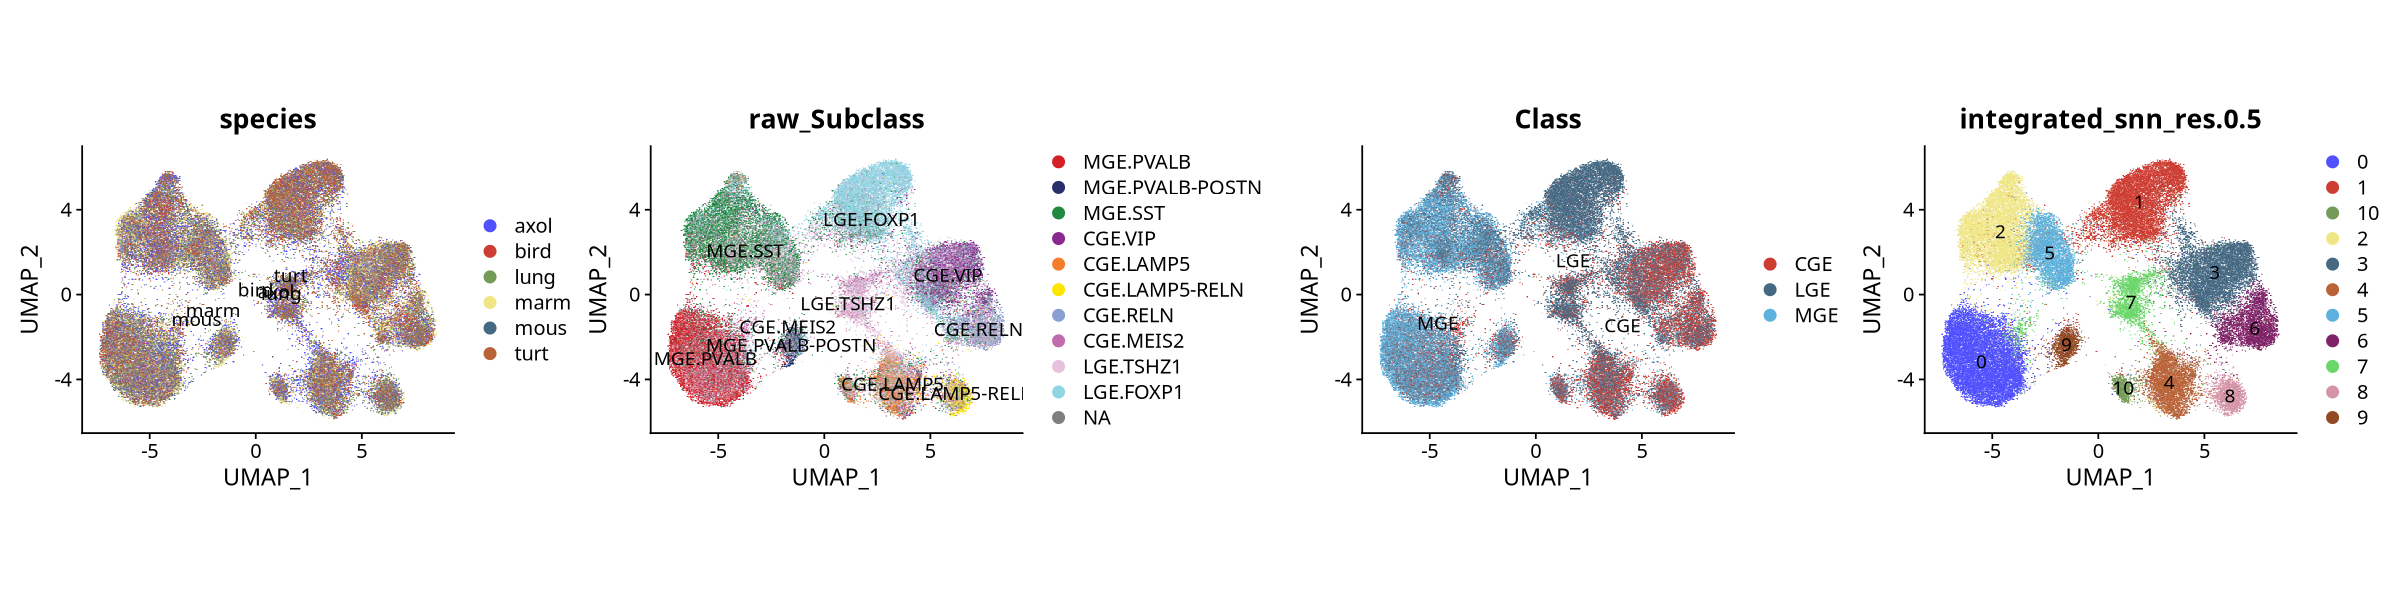

In [70]:
options(repr.plot.height=5,repr.plot.width=20)
DimPlot(obj_IN_SCT,reduction = 'umap',group.by='species',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()|
DimPlot(obj_IN_SCT,reduction = 'umap',group.by='raw_Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = Archr_col)+
coord_fixed()|
DimPlot(obj_IN_SCT,reduction = 'umap',group.by='Class',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC'))+
coord_fixed()|
DimPlot(obj_IN_SCT,reduction = 'umap',group.by='integrated_snn_res.0.5',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()

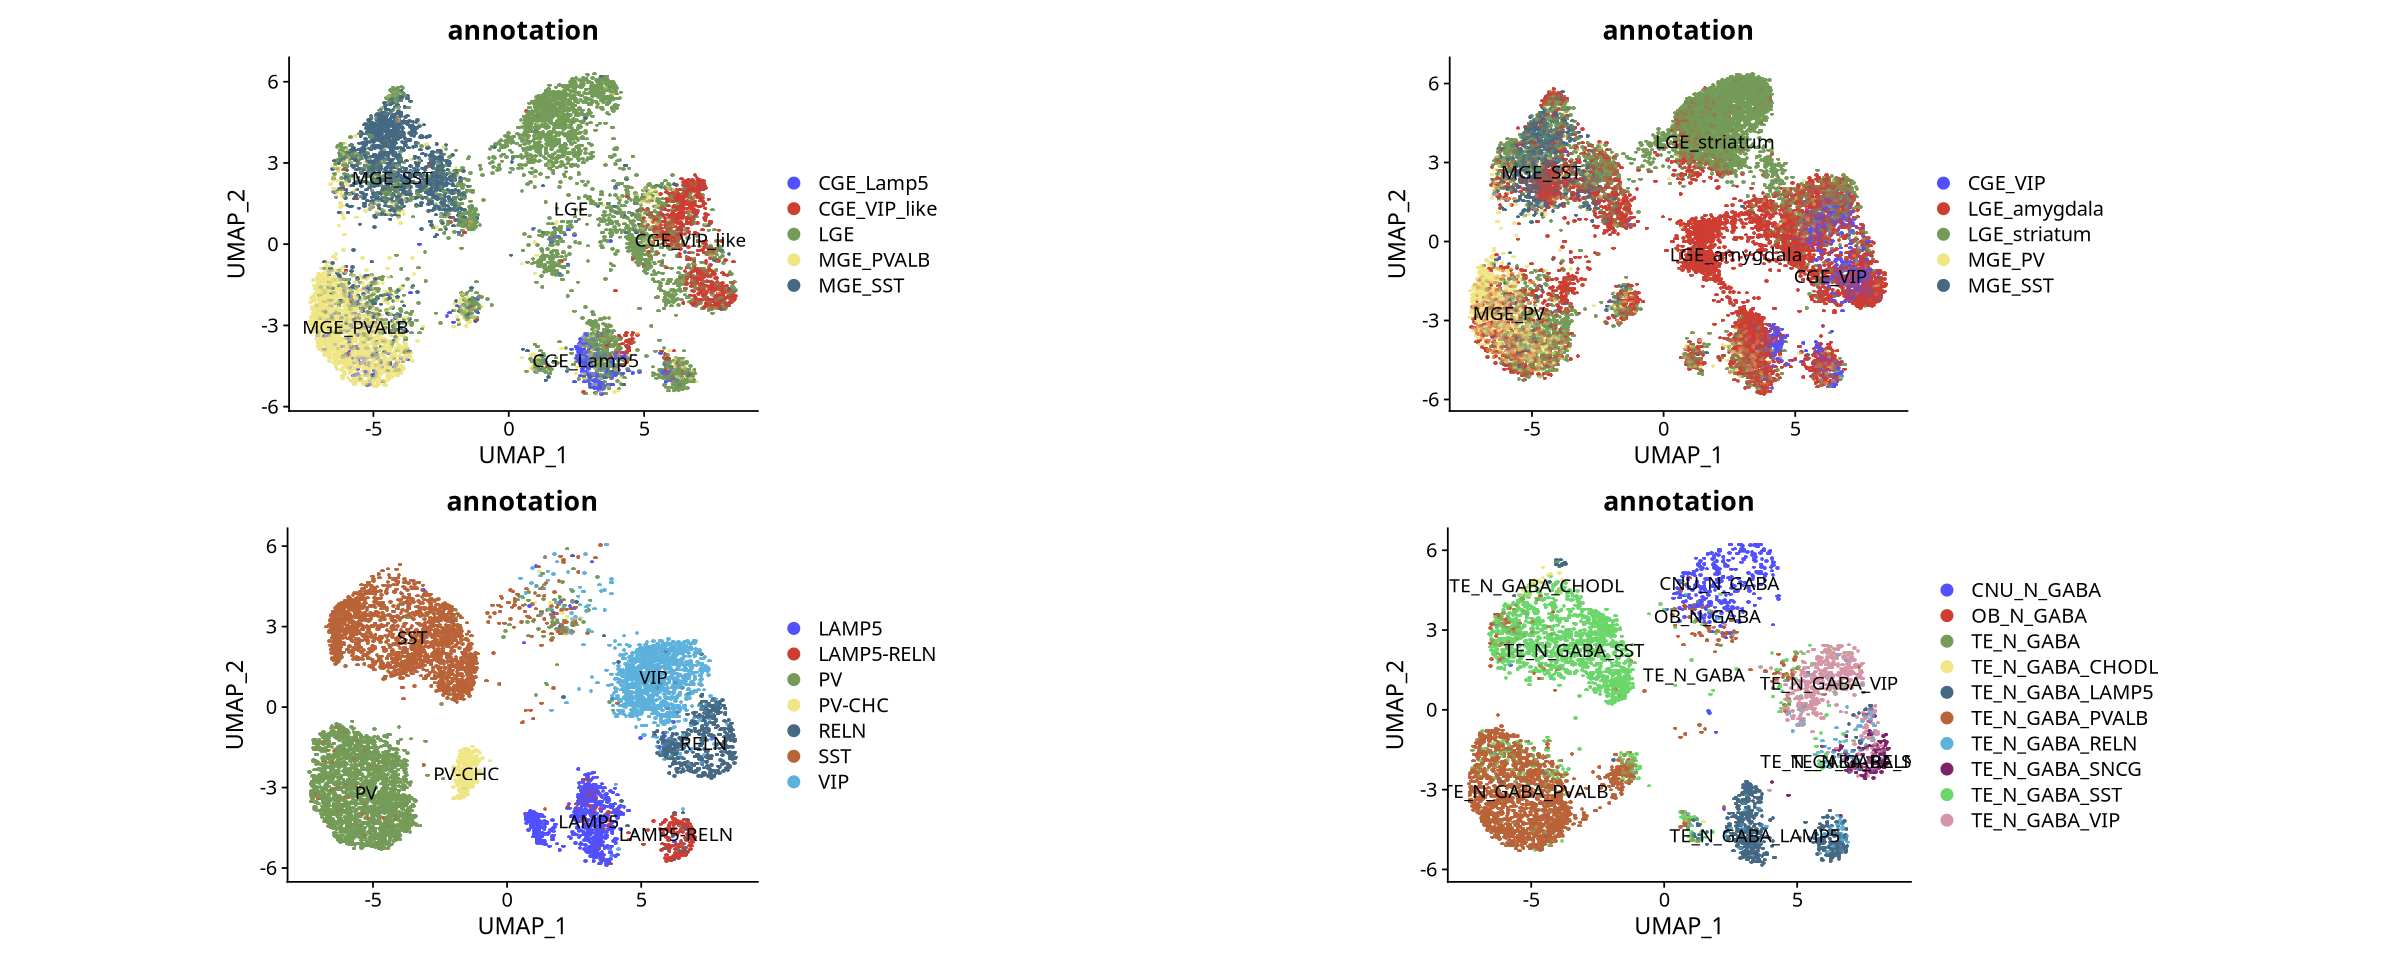

In [71]:
options(repr.plot.height=8,repr.plot.width=20)
(DimPlot(obj_IN_SCT[,grepl('CGE|LGE|MGE',obj_IN_SCT$annotation)&obj_IN_SCT$species=='bird'],reduction = 'umap',group.by='annotation',pt.size =3,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed()|
DimPlot(obj_IN_SCT[,grepl('CGE|LGE|MGE',obj_IN_SCT$annotation)&obj_IN_SCT$species=='turt'],reduction = 'umap',group.by='annotation',pt.size =3,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed())/
(DimPlot(obj_IN_SCT[,grepl('PV|SST|VIP|LAMP5|RELN',obj_IN_SCT$annotation)&obj_IN_SCT$species=='marm'],reduction = 'umap',group.by='annotation',pt.size =3,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed()|
DimPlot(obj_IN_SCT[,grepl('GABA',obj_IN_SCT$annotation)&obj_IN_SCT$species=='mous'],reduction = 'umap',group.by='annotation',pt.size =3,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed())

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


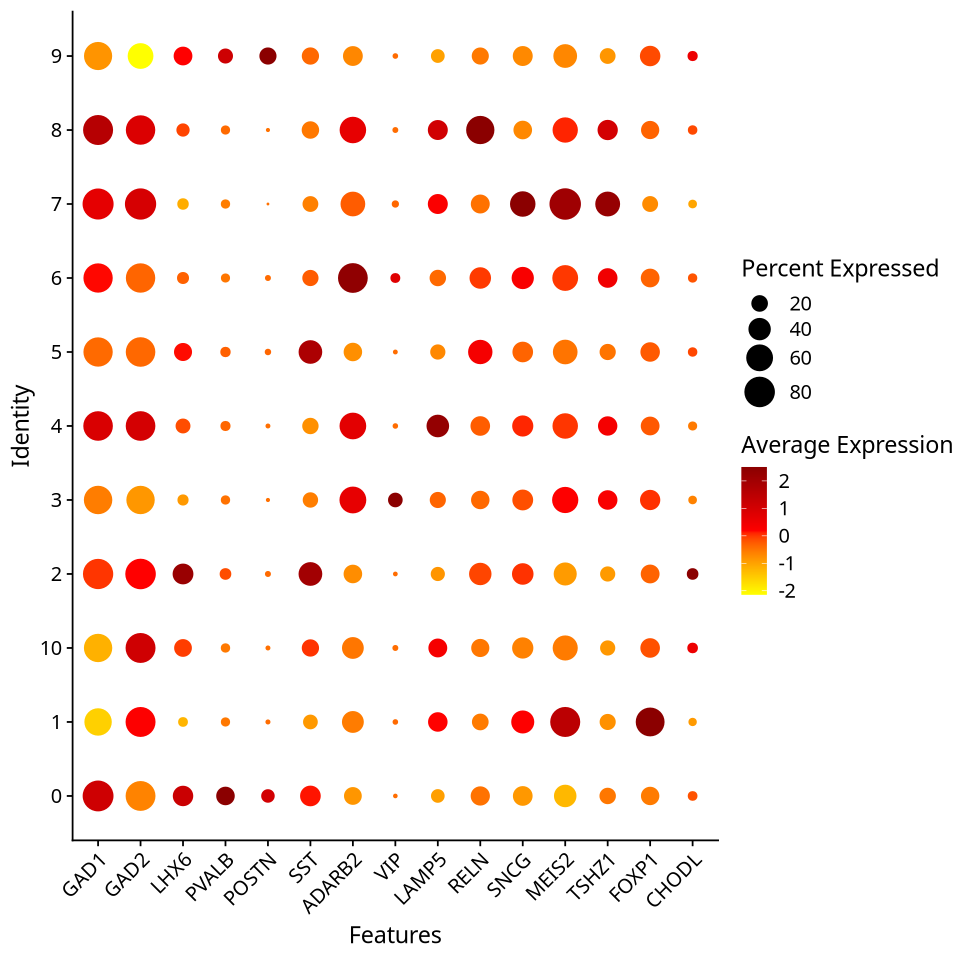

In [72]:
options(repr.plot.height=8,repr.plot.width=8)
x_labels <- c('GAD1','GAD2',      
              'LHX6','PVALB','POSTN','SST',
              'ADARB2','VIP','LAMP5','RELN','SNCG',
              'MEIS2','TSHZ1','FOXP1','CHODL')
#obj_IN_SCT$Subclass <- factor(obj_IN_SCT$Subclass, levels = c('PV','SST','VIP','LAMP5','MIX.1','MIX.2','MEIS2.1','MEIS2.2'))
obj_IN_SCT@active.assay <- 'RNA'
obj_IN_SCT <- NormalizeData(obj_IN_SCT)
DotPlot(obj_IN_SCT,group.by = 'integrated_snn_res.0.5',features = c('OG0009142','OG0010353',
                                                                     'OG0001689','OG0000302','OG0011443','OG0001262',
                                                                     'OG0010349','OG0005536','OG0008033','OG0006602','OG0002807',
                                                                     'OG0001296','OG0011026','OG0010427','OG0008633'),assay = 'RNA')+
scale_x_discrete(labels= x_labels)+
scale_color_gradientn(colours = c('yellow','red','darkred'))+
scale_size(range = c(0,8))+
theme(axis.text.x = element_text(angle=45,hjust=1,vjust=1))

In [91]:
obj_IN_SCT$Subclass <- 'None'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(0),]$Subclass <- 'MGE.PVALB'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(9),]$Subclass <- 'MGE.PVALB-POSTN'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(2,5),]$Subclass <- 'MGE.SST'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(3),]$Subclass <- 'CGE.VIP'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(6),]$Subclass <- 'CGE.RELN'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(8),]$Subclass <- 'CGE.LAMP5-RELN'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(4),]$Subclass <- 'CGE.LAMP5'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(10),]$Subclass <- 'CGE.LAMP5-PRKG1'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(7),]$Subclass <- 'LGE.TSHZ1'
obj_IN_SCT@meta.data[obj_IN_SCT@meta.data$integrated_snn_res.0.5%in%c(1),]$Subclass <- 'LGE.FOXP1'

In [55]:
obj_IN_SCT@active.assay <- 'RNA'
obj_IN_SCT <- NormalizeData(obj_IN_SCT)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


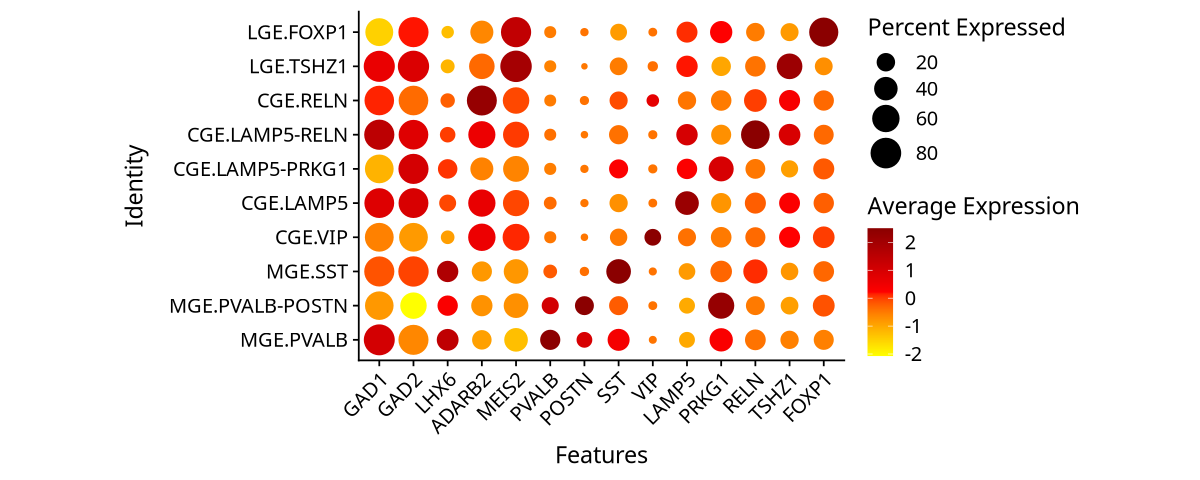

In [111]:
options(repr.plot.height=4,repr.plot.width=10)
obj_IN_SCT@active.assay <- 'RNA'
x_labels <- c('GAD1','GAD2',
              'LHX6','ADARB2', 'MEIS2',
              'PVALB','POSTN','SST',
              'VIP','LAMP5','PRKG1','RELN',
              'TSHZ1','FOXP1')
obj_IN_SCT$Subclass <- factor(obj_IN_SCT$Subclass, levels = c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1'))
p <- DotPlot(obj_IN_SCT,group.by = 'Subclass',features = c('OG0009142','OG0010353',
                                                      'OG0001689','OG0010349','OG0001296',
                                                      'OG0000302','OG0011443','OG0001262',
                                                      'OG0005536','OG0008033','OG0004584','OG0006602',
                                                      'OG0011026','OG0010427'),assay = 'RNA')+
scale_x_discrete(labels= x_labels)+
scale_color_gradientn(colours = c('yellow','red','darkred'))+
scale_size(range = c(1,8))+
theme(axis.text.x = element_text(angle=45,hjust=1,vjust=1))+
coord_fixed()
p

In [112]:
pdf('Plot/IN_Dotplot_marker.pdf',height=4,width=10)
p
dev.off()

pdf 
  2

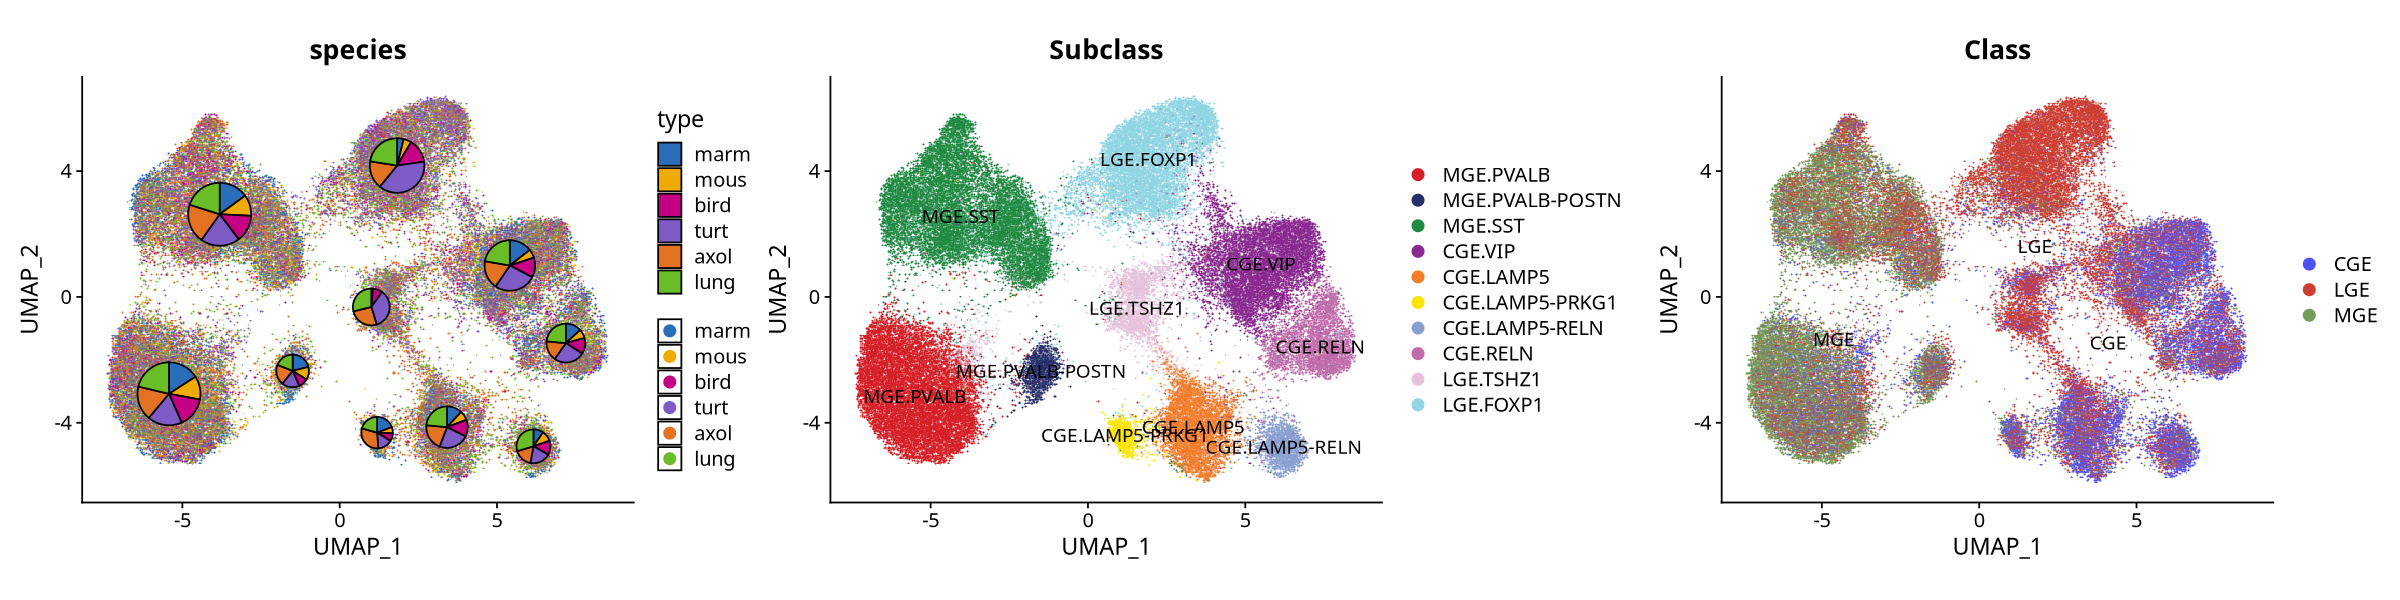

In [157]:
options(repr.plot.height=5,repr.plot.width=20)
obj_tmp <- obj_IN_SCT
piedf <- aggregate(list('UMAP1'=obj_tmp@reductions$umap@cell.embeddings[,1],'UMAP2'=obj_tmp@reductions$umap@cell.embeddings[,2]),by=list('Subclass'=obj_tmp$Subclass),mean)
piedf <- cbind(as.data.frame.array(table(obj_tmp@meta.data[,c('Subclass','species')])),piedf)
piedf$radius <- as.numeric(table(obj_tmp$Subclass))
piedf$radius <- (((piedf$radius-min(piedf$radius))/(max(piedf$radius)-min(piedf$radius)))+1)/2

p1 <- DimPlot(obj_tmp,reduction = 'umap',group.by='species',pt.size = 1.5,raster = T,label=F)+
geom_scatterpie(data=piedf,aes(x=UMAP1,y=UMAP2,r=radius),lwd=0.5,cols=c('marm','mous','bird','turt','axol','lung'),show.legend = TRUE)+
scale_color_manual(values = c(pal_bmj()(6)),breaks = c('marm','mous','bird','turt','axol','lung'))+
scale_fill_manual(values = c(pal_bmj()(6)),breaks = c('marm','mous','bird','turt','axol','lung'))+
coord_fixed()
p2 <- DimPlot(obj_tmp,reduction = 'umap',group.by='Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = Archr_col)+
coord_fixed()
p3 <- DimPlot(obj_tmp,reduction = 'umap',group.by='Class',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()
p1|p2|p3

In [158]:
pdf('Plot/IN_UMAP_subclass.pdf',height=5,width=20)
p1|p2
dev.off()

pdf 
  2

In [98]:
saveRDS(obj_IN_SCT,'obj_GABA_integrated_splitClass_final_20251117.rds')